In [1]:
import torch
import os
import random
import utils
import data_utils
import json

import cbm
import plots

In [7]:
# change this to the correct model dir, everything else should be taken care of
load_dir = "saved_models/chestxray_cbm_2025_04_14_22_28"
device = "cuda"

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args["dataset"]
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
model = cbm.load_cbm(load_dir, device)

d:\GitHub\Label-free-CBM\cbm.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  W_c = torch.load(os.path.join(load_dir ,"W_c.pt"), map_location=device)
d:\GitHub\Label-fre

In [8]:
val_d_probe = dataset+"_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_data(val_d_probe, preprocess=target_preprocess)
val_pil_data = data_utils.get_data(val_d_probe)

In [9]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

## Measure accuracy

In [10]:
accuracy = utils.get_accuracy_cbm(model, val_data_t, device)
print("Top-1 Accuracy: {:.2f}%".format(accuracy*100))

100%|██████████| 113/113 [05:02<00:00,  2.68s/it]

Top-1 Accuracy: 43.37%


In [11]:
topk_accuracy = utils.get_topk_accuracy_cbm(model, val_data_t, device, k=3)
print("Top-3 Accuracy: {:.2f}%".format(topk_accuracy*100))

100%|██████████| 113/113 [03:46<00:00,  2.00s/it]

Top-3 Accuracy: 67.45%


In [12]:
topk_accuracy = utils.get_topk_accuracy_cbm(model, val_data_t, device, k=5)
print("Top-5 Accuracy: {:.2f}%".format(topk_accuracy*100))

100%|██████████| 113/113 [04:04<00:00,  2.16s/it]

Top-5 Accuracy: 80.34%


## Show final layer weights for some classes

You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

In [13]:
to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{} [{:.4f}] {}".format(concepts[j], model.final.weight[i,j], classes[i]))

Output class:2 - Infiltration
Incoming weights:
- Abdominal wall defect [-0.1316] Infiltration
- Cardiovascular disease [0.0557] Infiltration
- Hyperinflated lungs [-0.1015] Infiltration
- Lung infection [-0.1331] Infiltration
- Size and shape of the mass [-0.0753] Infiltration
Abdominal disorder [0.0853] Infiltration
Biological process disruption [0.0808] Infiltration
Fluid imbalance disorder [0.2154] Infiltration


In [14]:
to_show = random.choices([i for i in range(len(classes))], k=2)

top_weights, top_weight_ids = torch.topk(model.final.weight, k=5, dim=1)
bottom_weights, bottom_weight_ids = torch.topk(model.final.weight, k=5, dim=1, largest=False)

for i in to_show:
    print("Class {} - {}".format(i, classes[i]))
    out = "Highest weights: "
    for j in range(top_weights.shape[1]):
        idx = int(top_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], top_weights[i, j])
    print(out)
    out = "Lowest weights: "
    for j in range(bottom_weights.shape[1]):
        idx = int(bottom_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], bottom_weights[i, j])
    print(out + "\n")

Class 2 - Infiltration
Highest weights: Fluid imbalance disorder:0.215, Abdominal disorder:0.085, Biological process disruption:0.081, - Cardiovascular disease:0.056, Blurring of vascular margins:0.022, 
Lowest weights: - Lung infection:-0.133, - Abdominal wall defect:-0.132, - Hyperinflated lungs:-0.102, - Size and shape of the mass:-0.075, - Size of the nodule:-0.047, 

Class 10 - Cardiomegaly
Highest weights: Digestive system disease:0.587, Double density sign:0.462, - Abdominal wall defect:0.415, Elevated diaphragm:0.319, - Alveoli:0.249, 
Lowest weights: - pulmonary consolidation:-0.316, - Lung parenchyma:-0.267, Connective tissue disorder:-0.228, Displacement of cardiac apex:-0.215, Chest wall:-0.215, 



In [15]:
# Some features may not have any non-zero outgoing weights, 
# i.e. these are not used by the model and should be deleted for better performance
weight_contribs = torch.sum(torch.abs(model.final.weight), dim=0)
print("Num concepts with outgoing weights:{}/{}".format(torch.sum(weight_contribs>1e-5), len(weight_contribs)))

Num concepts with outgoing weights:61/63


## Explain model reasoning for random inputs

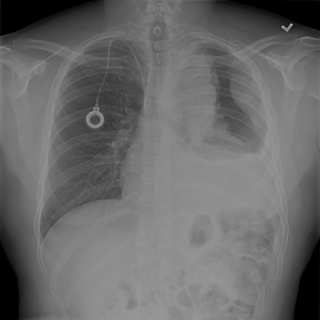

Image:6713 Ground Truth:Edema
Pred 1: Cardiomegaly (logit: 2.701, conf: 0.401)
Pred 2: Pneumonia (logit: 1.568, conf: 0.129)
Pred 3: Edema (logit: 1.537, conf: 0.125)
Pred 4: Atelectasis (logit: 0.867, conf: 0.064)
Pred 5: Pleural_thickening (logit: 0.747, conf: 0.057)


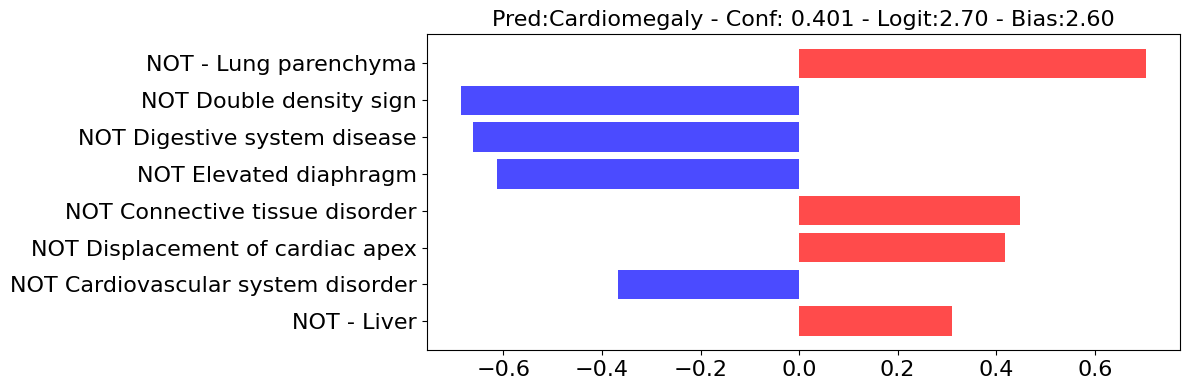

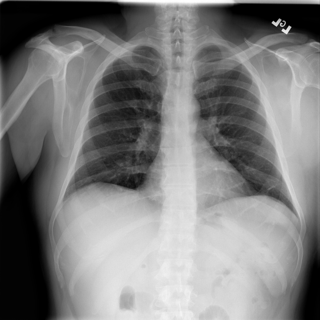

Image:20696 Ground Truth:Cardiomegaly
Pred 1: Cardiomegaly (logit: 2.802, conf: 0.499)
Pred 2: Pneumonia (logit: 1.509, conf: 0.137)
Pred 3: Edema (logit: 0.841, conf: 0.070)
Pred 4: Atelectasis (logit: 0.661, conf: 0.059)
Pred 5: Nodule (logit: 0.556, conf: 0.053)


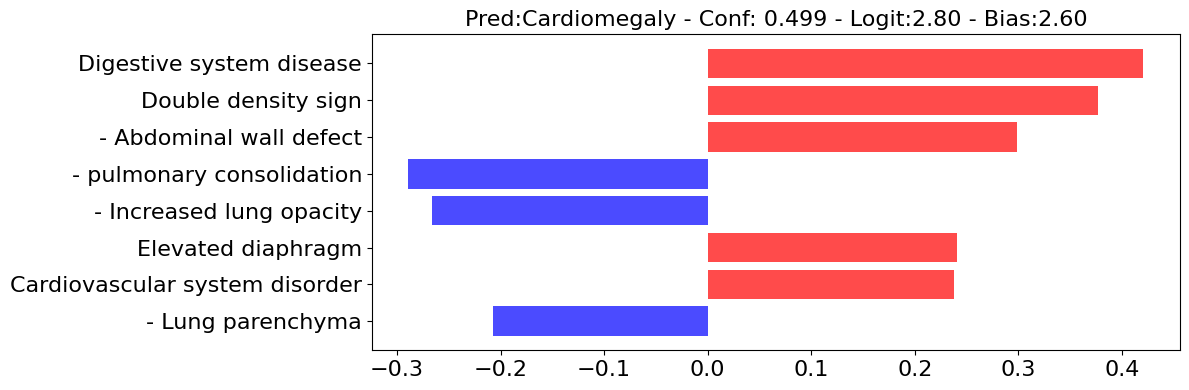

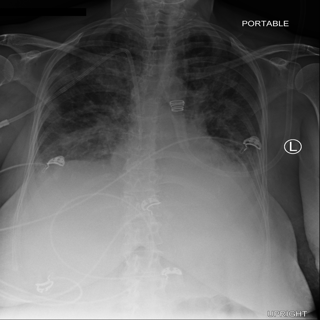

Image:11448 Ground Truth:Pneumonia
Pred 1: Pneumonia (logit: 1.960, conf: 0.221)
Pred 2: Cardiomegaly (logit: 1.825, conf: 0.193)
Pred 3: Edema (logit: 1.600, conf: 0.154)
Pred 4: Atelectasis (logit: 1.348, conf: 0.120)
Pred 5: Infiltration (logit: 0.537, conf: 0.053)


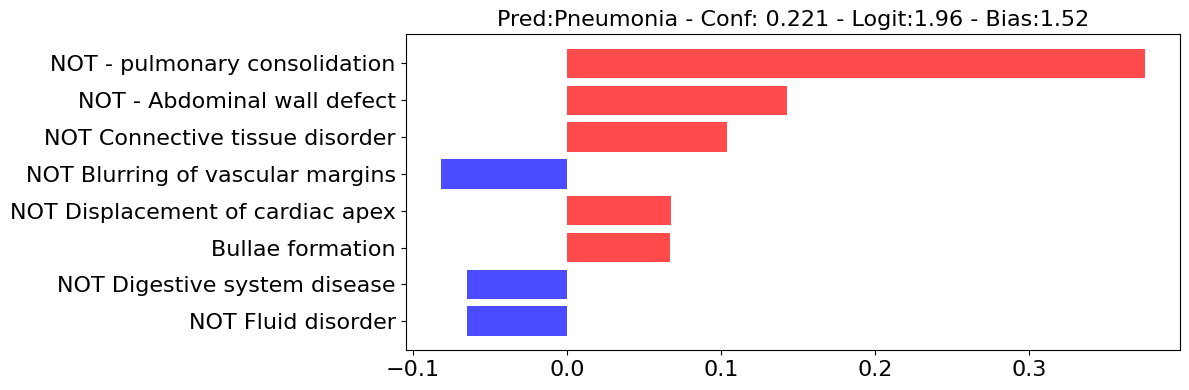

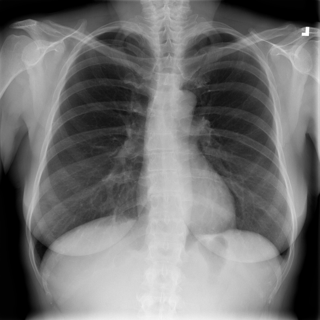

Image:13713 Ground Truth:Cardiomegaly
Pred 1: Cardiomegaly (logit: 2.906, conf: 0.507)
Pred 2: Pneumonia (logit: 1.655, conf: 0.145)
Pred 3: Edema (logit: 0.943, conf: 0.071)
Pred 4: Atelectasis (logit: 0.820, conf: 0.063)
Pred 5: Pleural_thickening (logit: 0.478, conf: 0.045)


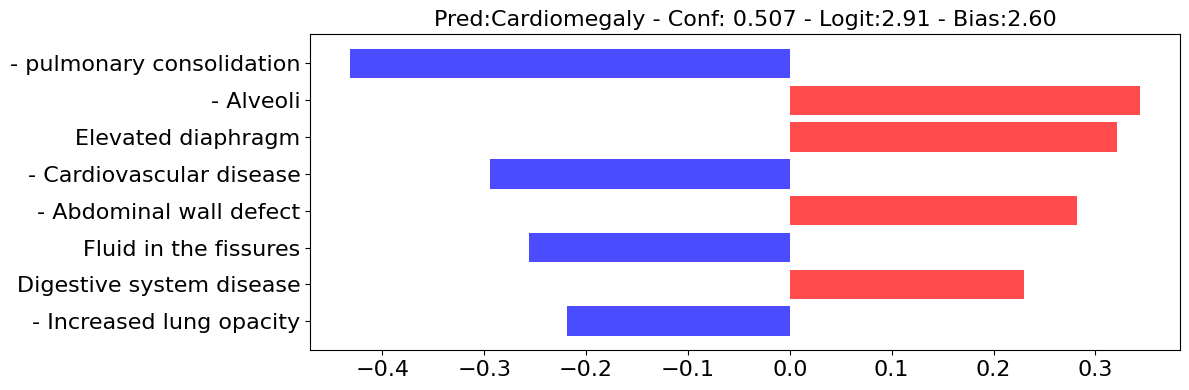

In [16]:
to_display = random.sample([i for i in range(len(val_pil_data))], k=4)

with torch.no_grad():
    for i in to_display:
        image, label = val_pil_data[i]
        x, _ = val_data_t[i]
        x = x.unsqueeze(0).to(device)
        display(image.resize([320,320]))
        
        outputs, concept_act = model(x)
        
        # Changed k from 2 to 5 for top 5 predictions
        top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=5)
        conf = torch.nn.functional.softmax(outputs[0], dim=0)
        
        # Modified print statement to show all 5 predictions
        print(f"Image:{i} Ground Truth:{classes[int(label)]}")
        for idx in range(5):
            print(f"Pred {idx+1}: {classes[top_classes[idx]]} (logit: {top_logit_vals[idx]:.3f}, conf: {conf[top_classes[idx]]:.3f})")
        
        for k in range(1):
            contributions = concept_act[0]*model.final.weight[top_classes[k], :]
            feature_names = [("NOT " if concept_act[0][i] < 0 else "") + concepts[i] for i in range(len(concepts))]
            values = contributions.cpu().numpy()
            max_display = min(int(sum(abs(values)>0.005))+1, 8)
            title = "Pred:{} - Conf: {:.3f} - Logit:{:.2f} - Bias:{:.2f}".format(classes[top_classes[k]],
                             conf[top_classes[k]], top_logit_vals[k], model.final.bias[top_classes[k]])
            plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=16)